# Performance Comparison: SA vs PA vs GA

This notebook reproduces the performance comparison figure from [arXiv:2510.19544](https://arxiv.org/abs/2510.19544), benchmarking three annealing algorithms on a 3D Ising spin glass ($L=10$, $N=1000$):

- **SA** (Simulated Annealing): standard local Metropolis updates through a temperature schedule.
- **PA** (Population Annealing): adds Boltzmann resampling at each temperature step, biasing the population toward low-energy configurations.
- **GA** (Global Annealing): augments PA-style annealing with MADE-based global moves that propose full-configuration updates via a learned autoregressive model.

We compare $\Delta E$ (the running minimum energy per spin) as a function of wall-clock time for three different time budgets.

In [1]:
import torch
import numpy as np
import sys
import time
from copy import deepcopy
import matplotlib.pyplot as plt

sys.path.append("./Code/Legacy/packages")
sys.path.append("./Code/Modern/optimization")

from geometry import *
from utilities import *
from data_loads import *
from monte_carlo import *
from made import *
from global_steps import *
from simulated_annealing import *
from population_annealing import *
from global_annealing import *

/home/celauro/miniconda3/envs/py36_env/lib/python3.6/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  print('Number of available GPUs: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Number of available GPUs:  3
Tesla V100S-PCIE-32GB
Tesla V100S-PCIE-32GB
Tesla V100S-PCIE-32GB
Computation device: cuda



## Fixed Parameters

All algorithms share the same coupling instance, temperature range, and number of local MC sweeps per step.

In [3]:
# Temperature range
Tstart = 1.92
Tend = 0.1

# Local Metropolis sweeps per temperature step
local_moves = 15

# GA-specific: global MADE moves and training hyper-parameters
global_moves = 5
num_epochs_start = 40
num_epochs_retrain = 1
batch_size = 256

# Temperature schedule type (logarithmic in T)
schedule = "logT"

# System size: 3D Ising spin glass on an L×L×L cubic lattice
L = 10
N = L * L * L

# Simulated Annealing

SA performs `local_moves` Metropolis sweeps at each temperature. No resampling or global moves.

![My Plot](notebook_images/SA.png)

In [4]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30  

# Disorder instance
seed = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# seed = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{seed}.txt', N).to(device)


temperatures, observ, elapsed_time = simulated_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)


minimum = torch.tensor(observ.get_observable_history("min_energy")).min()
print(local_moves, f"{len(temperatures)}", schedule, f"{minimum:.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_time:.3f}")


15 30 logT -1.68819 -1.65397 15.499


# Population Annealing

PA adds a Boltzmann reweighting + resampling step before the MC sweeps at each temperature, concentrating the population near lower-energy states.

![My Plot](notebook_images/PA.png)

In [5]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30  

# Disorder instance
seed = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# seed = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{seed}.txt', N).to(device)

temperatures, observ, elapsed_time = population_annealing(
    L, J, pop_size, local_moves, Tstart, Tend, Observables,
    num_temps_determiner=num_temps, schedule=schedule
)

minimum = torch.tensor(observ.get_observable_history("min_energy")).min()
print(local_moves, f"{len(temperatures)}", schedule, f"{minimum:.5f}", f'{observ.get_observable_history("mean_energy")[-1]:.5f}', f"{elapsed_time:.3f}")

15 30 logT -1.69287 -1.69232 16.261


# Global Annealing

GA trains a lightweight MADE network on the current population at the start and retrains it at each temperature step. Between local MC sweeps, it proposes full-configuration global moves via the learned model, accepted/rejected by a Metropolis criterion that corrects for the proposal bias.

![My Plot](notebook_images/GA.png)

In [4]:
# Population size (number of replicas)
pop_size = 100_000

# number of temperature steps
num_temps = 30  

# Disorder instance
seed = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# seed = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance

# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{seed}.txt', N).to(device)



temperatures, observ, elapsed_train_time, elapsed_annealing_time = global_annealing(
    L, J, pop_size, global_moves, local_moves, Tstart, Tend, Observables,
    schedule=schedule,
    num_epochs_start=num_epochs_start,
    num_epochs_retrain=num_epochs_retrain,
    batch_size=batch_size,
    num_temps_determiner=num_temps
)


minimum = torch.tensor(observ.get_observable_history("min_energy")).min()
print(global_moves, local_moves, f"{len(temperatures)}", schedule, f"{minimum:.5f}", f"{observ.get_observable_history('mean_energy')[-1]:.5f}", f"{elapsed_train_time:.3f}", f"{elapsed_annealing_time:.3f}")

5 15 30 logT -1.69300 -1.69268 13.357 152.949


# Algorithm Comparison

We sweep over three time budgets by varying `num_temps` (the number of temperature steps). More steps → longer runtime. The `logT` schedule spaces temperatures logarithmically between `Tstart` and `Tend`.

Each algorithm is run for each setting and we collect the per-step timestamps and running minimum energy.

In [11]:
# Keep the population size fixed
pop_size = 100_000

# Disorder instance
seed = 310411727  # hard instance
E_gs = -1.69300   # ground state energy for the hard instance
# seed = 10069     # easy instance (uncomment to switch)
#E_gs = -1.74178   # ground state energy for the easy instance


# Load coupling matrix
J = read_couplings(f'./Data/Alpha/Couplings/couplings_L{L}_R1_seed{seed}.txt', N).to(device)

# Three num_temps settings that produce roughly 15 s, 50 s, and 150 s runtimes
# (exact times depend on hardware; adjust if needed)
max_time_list = np.array([30, 60, 180])

# Storage: results[algo_name] = list of (elapsed_times, running_min) per num_temps
results = {"SA": [], "PA": [], "GA": []}

In [12]:
# factor of conversion between time and temperature depends on hardware
num_temps_list = (max_time_list*30/15).astype(int)

# Simulated annealing (SA)
for nt in num_temps_list:
    temperatures, observ, elapsed_time = simulated_annealing(
        L, J, pop_size, local_moves, Tstart, Tend, Observables,
        num_temps_determiner=nt, schedule=schedule
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    # keep only the entries recorded after start_time (skip the pre-thermalization entry)
    results["SA"].append((rt, rm[1:]))
    print(f"SA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  time = {elapsed_time:.1f} s")


SA  num_temps=  60  |  min_E/N = -1.69152  |  time = 31.6 s
SA  num_temps= 120  |  min_E/N = -1.69283  |  time = 64.2 s
SA  num_temps= 360  |  min_E/N = -1.69287  |  time = 193.1 s


In [43]:
# factor of conversion between time and temperature depends on hardware
num_temps_list = (max_time_list*30/16).astype(int)

# Population annealing (PA)
for nt in num_temps_list:
    temperatures, observ, elapsed_time = population_annealing(
        L, J, pop_size, local_moves, Tstart, Tend, Observables,
        num_temps_determiner=nt, schedule=schedule
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    results["PA"].append((rt, rm[1:]))
    print(f"PA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  time = {elapsed_time:.1f} s")

PA  num_temps=  56  |  min_E/N = -1.69287  |  time = 30.7 s
PA  num_temps= 112  |  min_E/N = -1.69300  |  time = 62.1 s
PA  num_temps= 337  |  min_E/N = -1.69300  |  time = 187.5 s


In [15]:
# factor of conversion between time and temperature depends on hardware
num_temps_list = (max_time_list*30/153).astype(int)

# Global annealing (GA)
for nt in num_temps_list:
    temperatures, observ, elapsed_train_time, elapsed_annealing_time = global_annealing(
        L, J, pop_size, global_moves, local_moves, Tstart, Tend, Observables,
        schedule=schedule,
        num_epochs_start=num_epochs_start,
        num_epochs_retrain=num_epochs_retrain,
        batch_size=batch_size,
        num_temps_determiner=nt
    )
    rt = observ.get_elapsed_times()
    rm = observ.get_running_min_energy()
    results["GA"].append((rt, rm[1:]))
    print(f"GA  num_temps={nt:>4d}  |  min_E/N = {rm[-1]:.5f}  |  train time = {elapsed_train_time:.3f} s  |  annealing time = {elapsed_annealing_time:.3f} s ")

GA  num_temps=   5  |  min_E/N = -1.68543  |  train time = 13.358 s  |  annealing time = 20.744 s 
GA  num_temps=  11  |  min_E/N = -1.69284  |  train time = 13.363 s  |  annealing time = 52.823 s 
GA  num_temps=  35  |  min_E/N = -1.69300  |  train time = 13.252 s  |  annealing time = 178.767 s 


## Performance Comparison Plot

We reproduce the figure from the paper: three panels (one per time budget), each showing $\Delta E$ = running minimum energy per spin vs. wall-clock runtime for SA (green), PA (red), and GA (blue).

The y-axis uses a log scale to highlight the orders-of-magnitude differences in convergence speed.

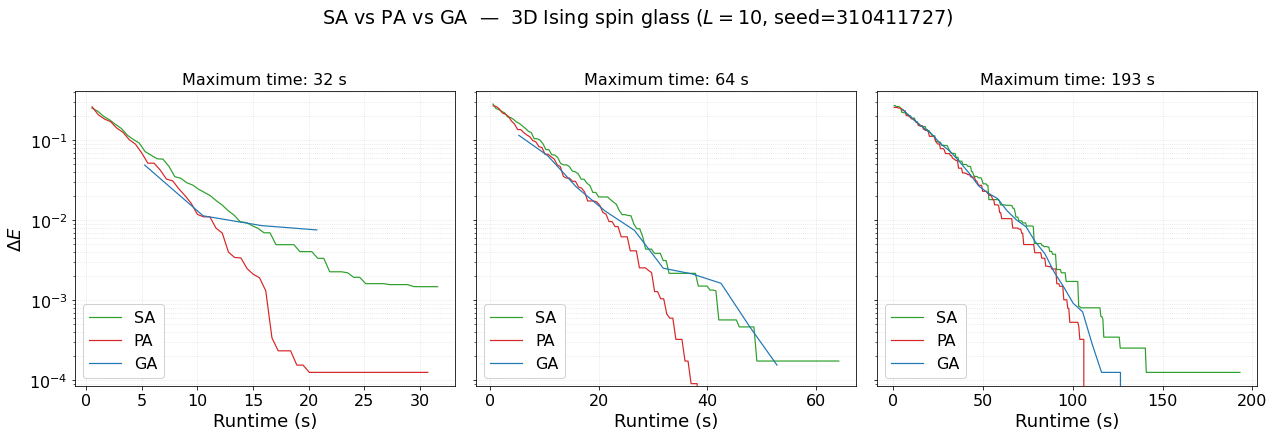

Figure saved to performance_comparison.png


In [48]:
plt.rcParams.update({'font.size': 16}) 
# To set the font size for axis labels
plt.rcParams['axes.labelsize'] = 18 
# To set the font size for tick labels (the numbers on the axes)
plt.rcParams['xtick.labelsize'] = 16 
plt.rcParams['ytick.labelsize'] = 16 
# You can also set the title size
plt.rcParams['axes.titlesize'] = 16 
# And the legend font size
plt.rcParams['legend.fontsize'] = 16



# --- Plotting ---
colors = {"SA": "#2ca02c", "PA": "#d62728", "GA": "#1f77b4"}  # green, red, blue

fig, axes = plt.subplots(1, len(num_temps_list), figsize=(6 * len(num_temps_list), 6),
                         sharey=True)

for idx, nt in enumerate(num_temps_list):
    ax = axes[idx]

    for algo in ["SA", "PA", "GA"]:
        rt, rm = results[algo][idx]
        # ΔE = running minimum energy per spin − ground-state energy per spin
        delta_e = np.array(rm) - E_gs
        ax.semilogy(rt, delta_e, label=algo, color=colors[algo], linewidth=1.2)

    max_time = max(
        results["SA"][idx][0][-1],
        results["PA"][idx][0][-1],
        results["GA"][idx][0][-1]
    )
    ax.set_title(f"Maximum time: {max_time:.0f} s")#, fontsize=12)
    ax.set_xlabel("Runtime (s)")#, fontsize=11)
    if idx == 0:
        ax.set_ylabel(r"$\Delta E$")#, fontsize=12)
    ax.legend(loc="lower left", framealpha=0.9)#, fontsize=10)
    ax.grid(True, which="both", ls=":", alpha=0.4)

fig.suptitle(f"SA vs PA vs GA  —  3D Ising spin glass ($L={L}$, seed={seed})",
              y=1.02),#fontsize=13)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figure saved to performance_comparison.png")

## Summary Table

Final minimum energies per spin and total runtimes for each algorithm and time budget.

In [38]:
print(f"{'Algo':<6} {'num_temps':>10} {'min E/N':>12} {'ΔE':>12} {'Runtime (s)':>14}")
print("-" * 60)
for algo in ["SA", "PA", "GA"]:
    for idx, nt in enumerate(num_temps_list):
        rt, rm = results[algo][idx]
        print(f"{algo:<6} {nt:>10d} {rm[-1]:>12.5f} {rm[-1] - E_gs:>12.5f} {rt[-1]:>14.1f}")

Algo    num_temps      min E/N           ΔE    Runtime (s)
------------------------------------------------------------
SA              5     -1.69152      0.00148           31.6
SA             11     -1.69283      0.00017           64.2
SA             35     -1.69287      0.00013          193.1
PA              5     -1.69287      0.00013           30.7
PA             11     -1.69300     -0.00000           62.0
PA             35     -1.69287      0.00013          187.4
GA              5     -1.68543      0.00757           20.7
GA             11     -1.69284      0.00016           52.8
GA             35     -1.69300     -0.00000          178.8
